In [1]:
import psutil
import time
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import IsolationForest
from sklearn.metrics import mean_absolute_error
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Function to get information about active processes with significant CPU and memory usage
def get_active_processes_with_high_usage(cpu_threshold=0, memory_threshold=0):
    processes_info = []  # List to store process information as dictionaries
    for process in psutil.process_iter(attrs=['pid', 'name', 'cpu_percent', 'memory_percent']):
        process_info = process.info
        name = process_info['name']
        cpu_percent = process_info['cpu_percent']
        memory_percent = process_info['memory_percent']
        
        # Filter processes based on CPU and memory usage thresholds
        if cpu_percent > cpu_threshold and memory_percent > memory_threshold:
            processes_info.append({'name': name, 'cpu_percent': cpu_percent, 'memory_percent': memory_percent})
    return processes_info

# Number of times to monitor active processes
monitoring_times = 10  # Change this to the desired number of times

In [3]:
# Collect data on active processes
process_data = []
for _ in range(monitoring_times):
    processes_info = get_active_processes_with_high_usage(cpu_threshold=0, memory_threshold=0)
    process_data.extend(processes_info)
    time.sleep(1)  # Wait for 1 second before the next measurement

# Create a DataFrame from the collected data
process_df = pd.DataFrame(process_data)

# Feature Engineering: Extract hour of the day as a feature
process_df['hour'] = pd.to_datetime('now').hour

# Define features (hour of the day) and target variables (CPU and memory usage percentages)
X = process_df[['hour']]
y_cpu = process_df['cpu_percent']
y_memory = process_df['memory_percent']

In [4]:
# Initialize variables to store total CPU and memory usage
total_cpu_percent = 0
total_memory_percent = 0

# Create an empty set to keep track of processed process names
processed_names = set()
process_instances = []
# Iterate through unique process names in the DataFrame
for name in process_df['name'].unique():
    # Filter instances of the current process
    instances = process_df[process_df['name'] == name]
    
    # Calculate total CPU and memory usage for the current process and accumulate the values
    total_cpu_percent += instances['cpu_percent'].sum()
    total_memory_percent += instances['memory_percent'].sum()
    
    # Calculate the number of instances
    instances_count = len(instances)
    
    # Calculate overall CPU and memory usage
    overall_cpu_percent = total_cpu_percent / instances_count
    overall_memory_percent = total_memory_percent / instances_count
    
    # Store instances information for the current process
    process_instances.append({'name': name, 'overall_cpu_percent': overall_cpu_percent, 'overall_memory_percent': overall_memory_percent, 'instances_count': instances_count})

In [5]:
for process_info in process_instances:
    print(f"Name: {process_info['name']}, Overall CPU Usage: {process_info['overall_cpu_percent']:.2f}%, Overall Memory Usage: {process_info['overall_memory_percent']:.2f}%, Instances: {process_info['instances_count']}")

# Calculate total CPU and memory usage across all processes
# Calculate total CPU and memory usage across all processes
total_instances_count = len(process_df)
total_cpu_percent /= total_instances_count
total_memory_percent /= total_instances_count

Name: mysqld, Overall CPU Usage: 0.96%, Overall Memory Usage: 2.45%, Instances: 7
Name: gnome-keyring-daemon, Overall CPU Usage: 7.70%, Overall Memory Usage: 17.19%, Instances: 1
Name: Xorg, Overall CPU Usage: 5.17%, Overall Memory Usage: 2.95%, Instances: 9
Name: gnome-shell, Overall CPU Usage: 11.74%, Overall Memory Usage: 5.16%, Instances: 8
Name: xdg-desktop-portal-gtk, Overall CPU Usage: 94.90%, Overall Memory Usage: 41.44%, Instances: 1
Name: mutter-x11-frames, Overall CPU Usage: 95.90%, Overall Memory Usage: 42.32%, Instances: 1
Name: ibus-daemon, Overall CPU Usage: 102.60%, Overall Memory Usage: 42.39%, Instances: 1
Name: ibus-extension-gtk3, Overall CPU Usage: 106.40%, Overall Memory Usage: 42.57%, Instances: 1
Name: ibus-engine-simple, Overall CPU Usage: 107.40%, Overall Memory Usage: 42.62%, Instances: 1
Name: brave, Overall CPU Usage: 12.88%, Overall Memory Usage: 6.01%, Instances: 9
Name: spotify, Overall CPU Usage: 8.60%, Overall Memory Usage: 4.20%, Instances: 21
Name: c

In [6]:
# Display the total CPU and memory usage across all processes
# Assuming 8 cores and 16 threads
total_cores = 8

# Calculate normalized CPU usage (per single core)
normalized_total_cpu_percent = total_cpu_percent / total_cores

# Calculate absolute memory usage in gigabytes (assuming 16 GB of RAM)
total_physical_memory_gb = 16  # 16 GB of RAM
absolute_total_memory_gb = total_memory_percent * total_physical_memory_gb / 100

# Display normalized CPU usage and absolute memory usage
print(f"\nNormalized Total CPU Usage (Per Single Core): {normalized_total_cpu_percent:.2f}%")
print(f"Absolute Total Memory Usage: {absolute_total_memory_gb:.2f} GB")


Normalized Total CPU Usage (Per Single Core): 0.74%
Absolute Total Memory Usage: 0.19 GB


In [7]:
# Split the data into training and testing sets
X_train, X_test, y_cpu_train, y_cpu_test, y_memory_train, y_memory_test = train_test_split(
    X, y_cpu, y_memory, test_size=0.2, random_state=42)

# Train separate models for CPU and memory usage prediction
cpu_model = RandomForestRegressor(random_state=42)
memory_model = RandomForestRegressor(random_state=42)

cpu_model.fit(X_train, y_cpu_train)
memory_model.fit(X_train, y_memory_train)

RandomForestRegressor(random_state=42)

In [8]:
# Predict CPU and memory usage on the test data
cpu_predictions = cpu_model.predict(X_test)
memory_predictions = memory_model.predict(X_test)

# Calculate Mean Absolute Error for CPU and memory usage predictions
cpu_mae = mean_absolute_error(y_cpu_test, cpu_predictions)
memory_mae = mean_absolute_error(y_memory_test, memory_predictions)
print(f"Mean Absolute Error for CPU Usage Prediction: {cpu_mae:.2f}")
print(f"Mean Absolute Error for Memory Usage Prediction: {memory_mae:.2f}")


Mean Absolute Error for CPU Usage Prediction: 6.55
Mean Absolute Error for Memory Usage Prediction: 0.61


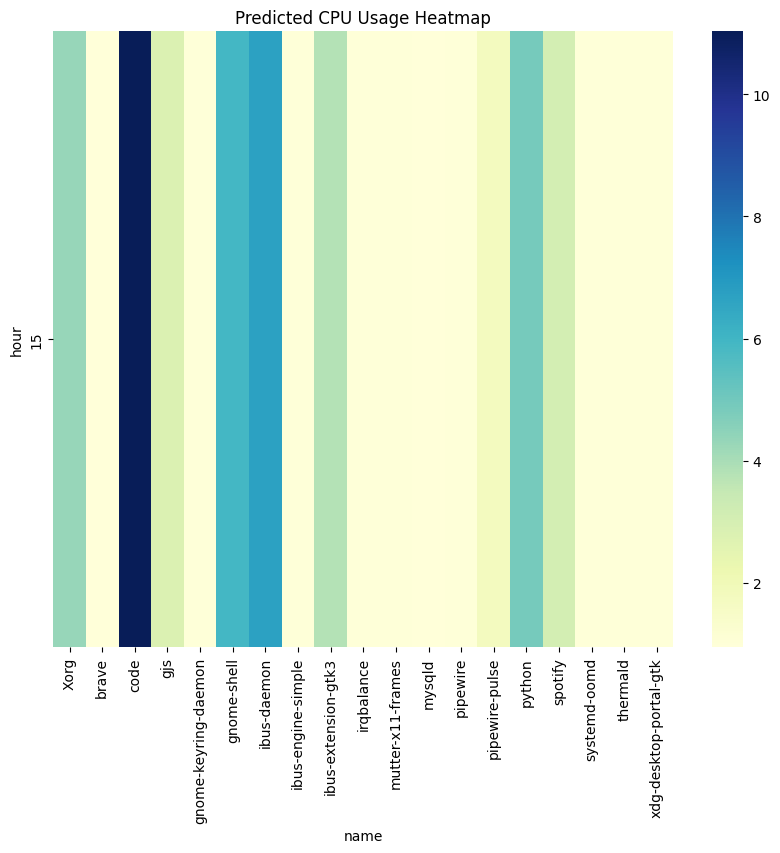

In [9]:
# Heatmap Visualization of Predicted CPU Usage
plt.figure(figsize=(10, 8))
sns.heatmap(process_df.pivot_table(index='hour', columns='name', values='cpu_percent', aggfunc='mean'), cmap="YlGnBu")
plt.title("Predicted CPU Usage Heatmap")
plt.show()


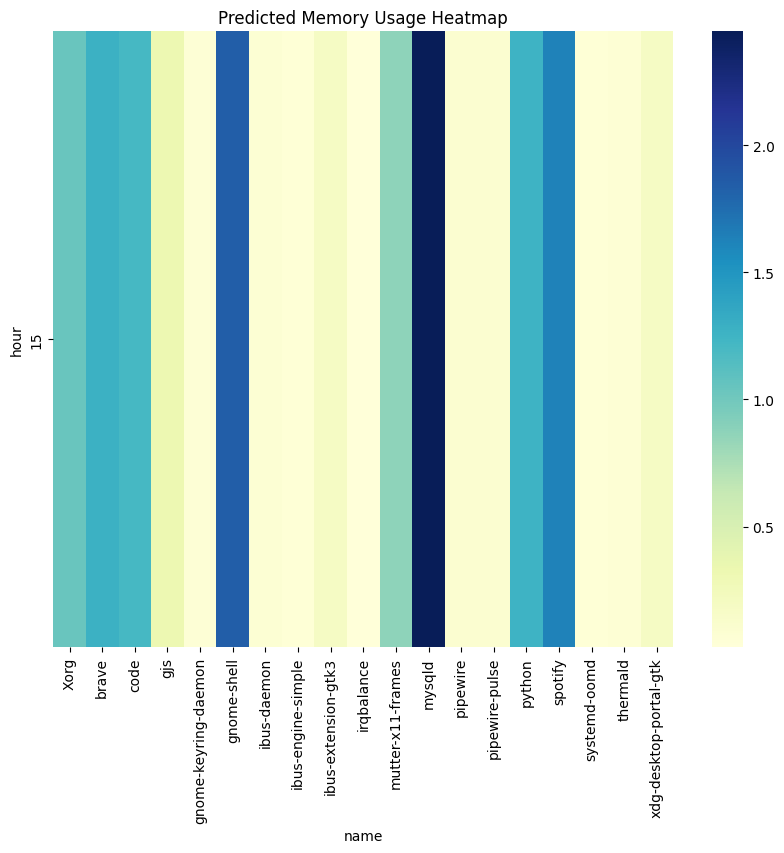

In [10]:
# Heatmap Visualization of Predicted Memory Usage
plt.figure(figsize=(10, 8))
sns.heatmap(process_df.pivot_table(index='hour', columns='name', values='memory_percent', aggfunc='mean'), cmap="YlGnBu")
plt.title("Predicted Memory Usage Heatmap")
plt.show()

In [11]:
#Detect Memory and CPU Anomalies
# Create a DataFrame from the collected data
process_df = pd.DataFrame(process_data)

# Define features (CPU and memory usage percentages)
X = process_df[['cpu_percent', 'memory_percent']]

# Initialize Isolation Forest models for CPU and memory anomaly detection
cpu_isolation_forest = IsolationForest(contamination=0.01, random_state=42)
memory_isolation_forest = IsolationForest(contamination=0.01, random_state=42)

# Fit the Isolation Forest models
cpu_isolation_forest.fit(X)
memory_isolation_forest.fit(X)

IsolationForest(contamination=0.01, random_state=42)

In [12]:
# Predict anomaly labels (-1 for anomaly, 1 for normal) for CPU and memory usage
process_df['cpu_anomaly'] = cpu_isolation_forest.predict(X)
process_df['memory_anomaly'] = memory_isolation_forest.predict(X)

# Filter anomalies for CPU and memory usage
cpu_anomalies = process_df[process_df['cpu_anomaly'] == -1]
memory_anomalies = process_df[process_df['memory_anomaly'] == -1]

# Print detected CPU anomalies
print("Detected CPU Anomalies:")
print(cpu_anomalies)

# Print detected memory anomalies
print("Detected Memory Anomalies:")
print(memory_anomalies)

Detected CPU Anomalies:
     name  cpu_percent  memory_percent  cpu_anomaly  memory_anomaly
15   code        120.1        1.941825           -1              -1
128  code         59.7        1.689116           -1              -1
Detected Memory Anomalies:
     name  cpu_percent  memory_percent  cpu_anomaly  memory_anomaly
15   code        120.1        1.941825           -1              -1
128  code         59.7        1.689116           -1              -1
